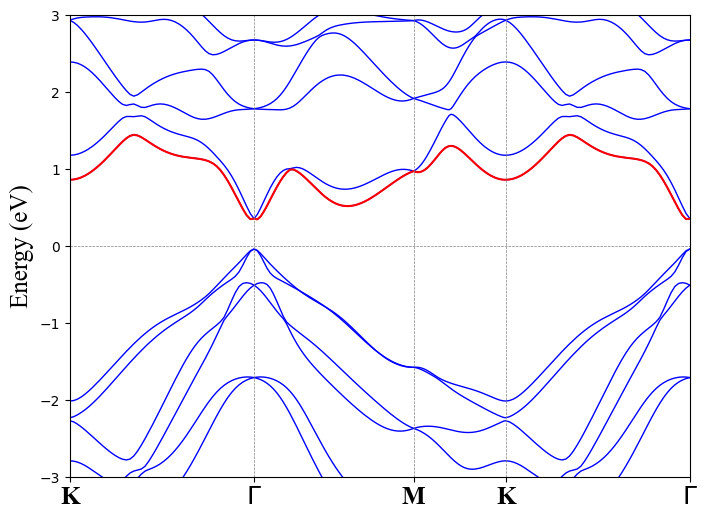

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data_band = np.loadtxt("REFORMATTED_BAND.dat")

k = data_band[:,0]
E = data_band[:,1:]

high_symmetry_points = [0, 0.982, 1.833, 2.324, max(k)]
labels = ['K', '$\Gamma$', 'M', 'K', '$\Gamma$']

plt.figure(figsize=(8, 6))
for i in range(E.shape[1]):
    plt.plot(k, E[:, i], color='blue',lw=1)
#plt.plot(k, E[:, 20], color='red', lw=1.5, label='Valence Band')
for i in range(len(high_symmetry_points)):
    plt.axvline(x=high_symmetry_points[i], color='gray', linestyle='--', lw=0.5)

plt.axhline(y=0, color='gray', linestyle='--', lw=0.5)    

plt.xticks(high_symmetry_points, labels,fontsize=18,fontname="Times New Roman", fontweight="bold")
plt.ylabel('Energy (eV)',fontsize=18,fontname="Times New Roman")
#plt.title('Band Structure of BiSb monolayer')
plt.xlim(min(k), max(k))
plt.ylim(-3, 3)
plt.savefig('BiSb_band_structure.png', dpi=300)
plt.show() 

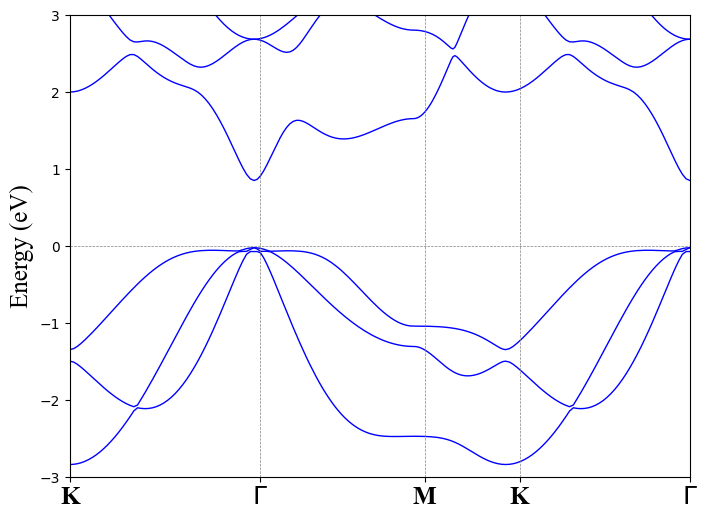

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data_band = np.loadtxt("wosoc-REFORMATTED_BAND.dat")

k = data_band[:,0]
E = data_band[:,1:]

high_symmetry_points = [0, 0.982, 1.833, 2.324, max(k)]
labels = ['K', '$\Gamma$', 'M', 'K', '$\Gamma$']

plt.figure(figsize=(8, 6))
for i in range(E.shape[1]):
    plt.plot(k, E[:, i], color='blue',lw=1)
#plt.plot(k, E[:, 20], color='red', lw=1.5, label='Valence Band')
for i in range(len(high_symmetry_points)):
    plt.axvline(x=high_symmetry_points[i], color='gray', linestyle='--', lw=0.5)

plt.axhline(y=0, color='gray', linestyle='--', lw=0.5)    

plt.xticks(high_symmetry_points, labels,fontsize=18,fontname="Times New Roman", fontweight="bold")
plt.ylabel('Energy (eV)',fontsize=18,fontname="Times New Roman")
#plt.title('Band Structure of BiSb monolayer')
plt.xlim(min(k), max(k))
plt.ylim(-3, 3)
plt.savefig('wosoc-BiSb_band_structure.png', dpi=300)
plt.show() 

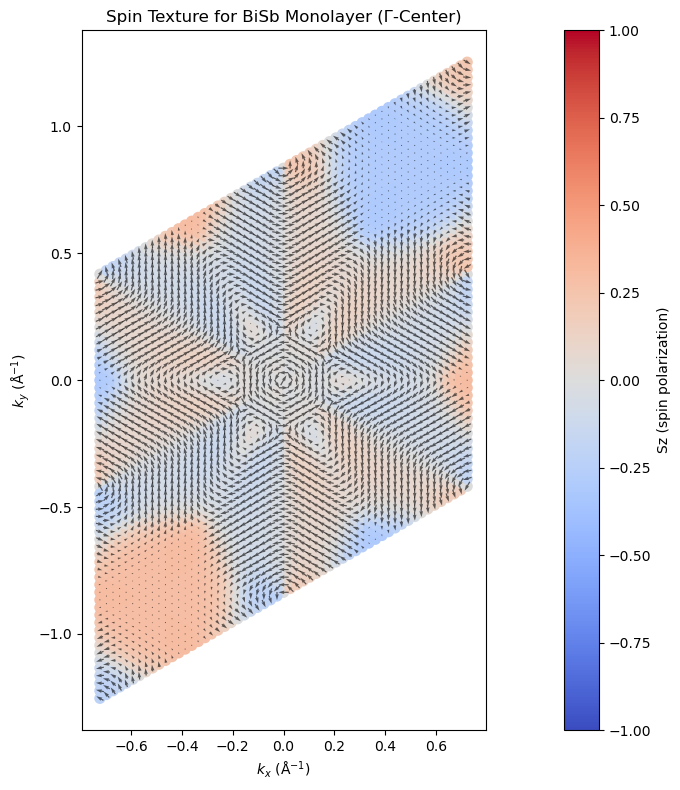

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

data_spin = np.loadtxt(
    "21-SPINTEXTURE_2D_GAMMA_CENTER.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx = data_spin[:, 0]
ky = data_spin[:, 1]
Sx = data_spin[:, 2]
Sy = data_spin[:, 3]
Sz = data_spin[:, 4]

fig, ax = plt.subplots(figsize=(16, 8))

# Background: scatter colored by Sz
norm = Normalize(vmin=-1, vmax=1)
sc = ax.scatter(kx, ky, c=Sz, cmap="coolwarm", norm=norm, s=50, zorder=1)
fig.colorbar(sc, ax=ax, label="Sz (spin polarization)")

# Foreground: quiver arrows showing in-plane spin (Sx, Sy)
ax.quiver(kx, ky, Sx, Sy,
          pivot="mid",
          scale=8,          # lower = longer arrows; tune to your grid
          scale_units="xy",
          width=0.003,
          color="black",
          alpha=0.6,
          zorder=2)

ax.set_xlabel(r"$k_x$ (Å$^{-1}$)")
ax.set_ylabel(r"$k_y$ (Å$^{-1}$)")
ax.set_title("Spin Texture for BiSb Monolayer (Γ-Center)")
ax.set_aspect("equal")

plt.tight_layout()
#plt.savefig("spin_texture.png", dpi=150, bbox_inches="tight")
plt.show()

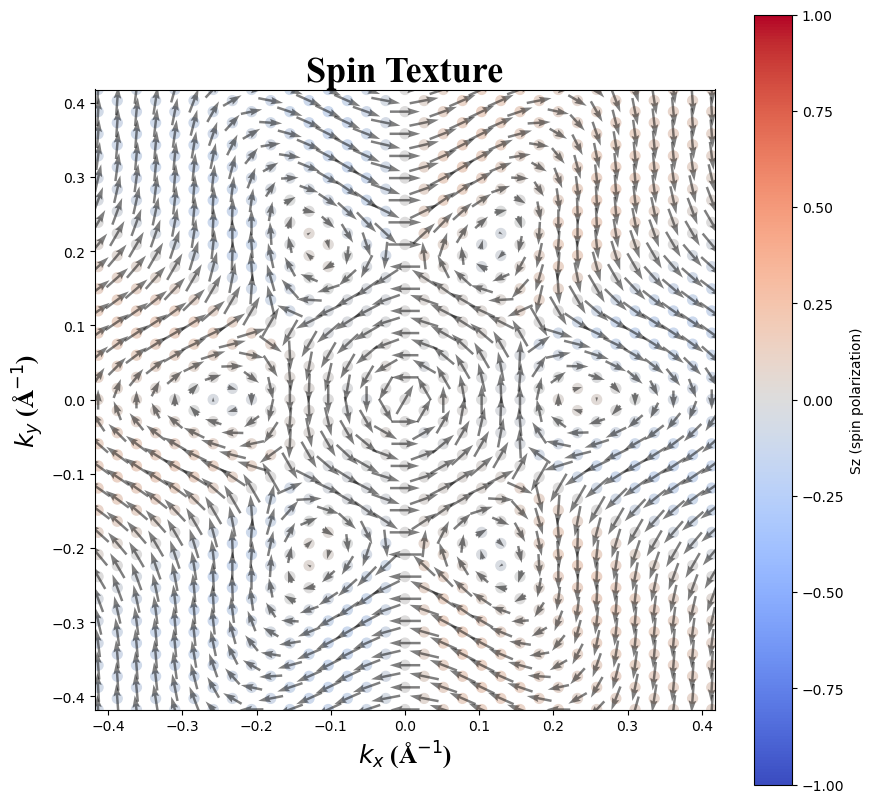

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

data_spin = np.loadtxt(
    "21-SPINTEXTURE_2D_GAMMA_CENTER.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx = data_spin[:, 0]
ky = data_spin[:, 1]
Sx = data_spin[:, 2]
Sy = data_spin[:, 3]
Sz = data_spin[:, 4]

# ── Crop to the largest square fully covered by data ─────────────────────────
kx_unique = np.unique(kx)
ky_unique = np.unique(ky)

# For each ky row, find the kx extent; take the tightest (inner square)
kx_min_per_ky = [kx[ky == y].min() for y in ky_unique]
kx_max_per_ky = [kx[ky == y].max() for y in ky_unique]
kx_lo = np.max(kx_min_per_ky)
kx_hi = np.min(kx_max_per_ky)

# For each kx column, find the ky extent; take the tightest
ky_min_per_kx = [ky[kx == x].min() for x in kx_unique]
ky_max_per_kx = [ky[kx == x].max() for x in kx_unique]
ky_lo = np.max(ky_min_per_kx)
ky_hi = np.min(ky_max_per_kx)

# Use the tightest bound across both axes to guarantee no empty corners
k_sq = min(abs(kx_lo), abs(kx_hi), abs(ky_lo), abs(ky_hi))

mask = (np.abs(kx) <= k_sq) & (np.abs(ky) <= k_sq)

kx_p, ky_p = kx[mask], ky[mask]
Sx_p, Sy_p, Sz_p = Sx[mask], Sy[mask], Sz[mask]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

norm = Normalize(vmin=-1, vmax=1)
sc = ax.scatter(kx_p, ky_p, c=Sz_p, cmap="coolwarm", norm=norm, s=50, zorder=1)
fig.colorbar(sc, ax=ax, label="Sz (spin polarization)")

ax.quiver(kx_p, ky_p, Sx_p, Sy_p,
          pivot="mid",
          scale=8,
          scale_units="xy",
          width=0.004,
          color="black",
          alpha=0.5,
          zorder=2)

ax.set_xlim(-k_sq, k_sq)
ax.set_ylim(-k_sq, k_sq)
ax.set_xlabel(r"$k_x$ (Å$^{-1}$)",fontsize=18,fontname="Times New Roman", fontweight="bold")
ax.set_ylabel(r"$k_y$ (Å$^{-1}$)",fontsize=18,fontname="Times New Roman", fontweight="bold")
ax.set_title("Spin Texture",fontsize=26,fontname="Times New Roman", fontweight="bold")
ax.set_aspect("equal")


plt.savefig("spin_texture.png", dpi=150, bbox_inches="tight")
plt.show()


C:\Users\furka\AppData\Local\Temp\ipykernel_22212\2389085055.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_bi = pd.read_csv(r"PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_22212\2389085055.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sb = pd.read_csv(r"PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


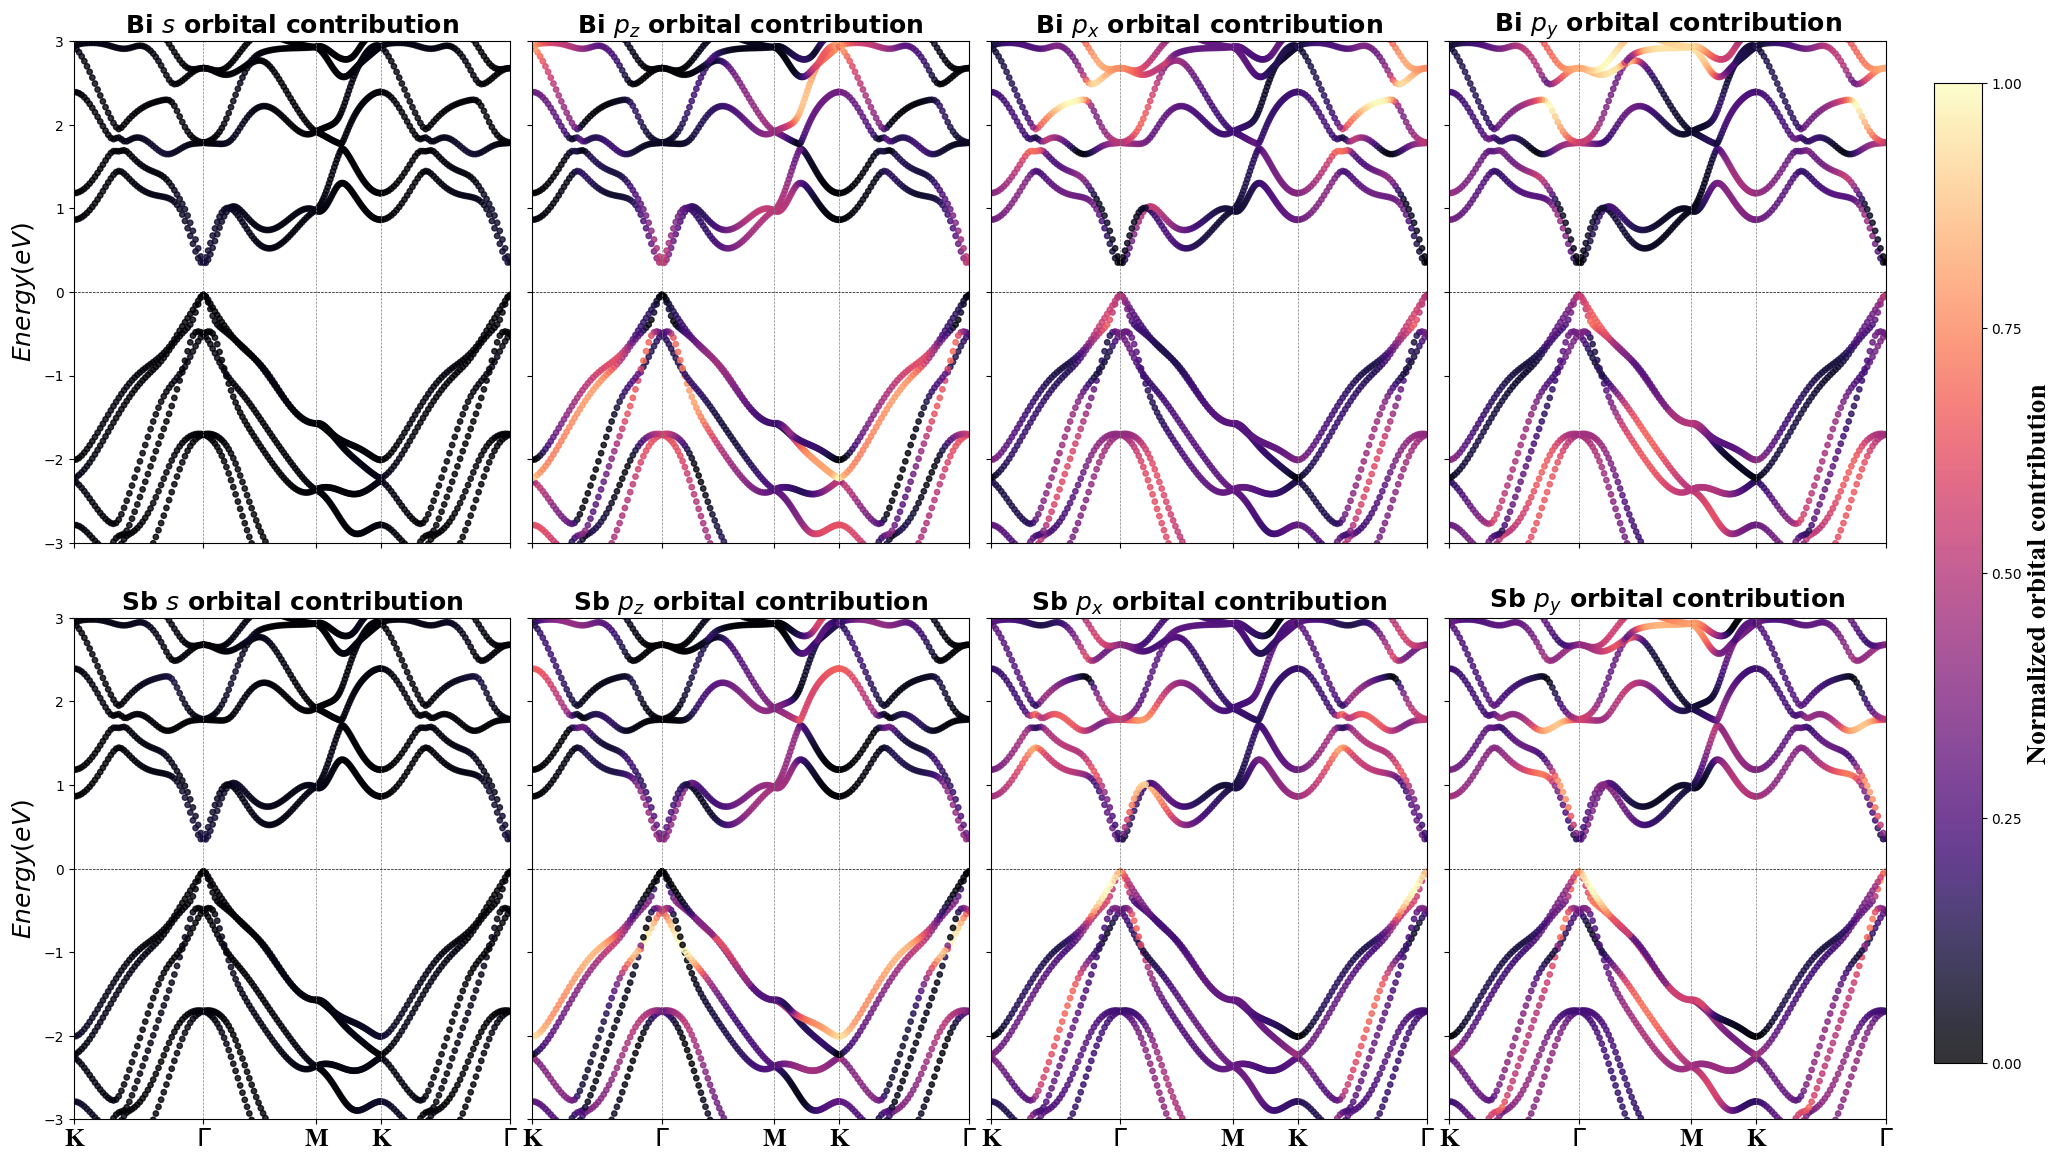

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load data for both atoms ---
data_bi = pd.read_csv(r"PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
data_sb = pd.read_csv(r"PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data_bi[0])
e = np.array(data_bi[1])

# --- Extract raw values ---
bi_vals = [data_bi[i].values.astype(float) for i in range(2, 6)]  # s, px, py, pz
sb_vals = [data_sb[i].values.astype(float) for i in range(2, 6)]

# --- Normalize each orbital INDEPENDENTLY to [0, 1] ---
def local_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

bi_norms = [local_norm(v) for v in bi_vals]
sb_norms = [local_norm(v) for v in sb_vals]


orbitals = [bi_norms[0],bi_norms[2], bi_norms[3], bi_norms[1],
            sb_norms[0],sb_norms[2], sb_norms[3], sb_norms[1]] 

names = ['Bi $s$', 'Bi $p_z$', 'Bi $p_x$', 'Bi $p_y$',
         'Sb $s$',  'Sb $p_z$', 'Sb $p_x$', 'Sb $p_y$']

cmap     = 'magma'

high_symmetry_points = [0, 0.982, 1.833, 2.324, 3.306]
high_symmetry_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

fig, axes = plt.subplots(2, 4, figsize=(24, 14), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, hspace=0.15, wspace=0.05)
axes = axes.flatten()

last_scatter = None

for idx, (orbital, name) in enumerate(zip(orbitals, names)):
    ax = axes[idx]

    scatter = ax.scatter(
        k, e,
        c=orbital,
        s=15, cmap=cmap, alpha=0.8,
        vmin=0, vmax=1
    )
    last_scatter = scatter

    ax.set_title(f'{name} orbital contribution', fontsize=18, fontweight='bold')
    ax.set_ylim(-3, 3)
    ax.set_xlim(min(k), max(k))

    for x in high_symmetry_points:
        ax.axvline(x=x, color='gray', linestyle='--', lw=0.5)
    ax.axhline(0, ls='--', lw=0.5, color='black')

    # x-axis tick labels for all rows (since they share x-axis)
    ax.set_xticks(high_symmetry_points)
    ax.set_xticklabels(high_symmetry_labels,fontsize=18,fontname="Times New Roman", fontweight="bold")

    # y-axis label only on left column
    if idx % 4 == 0:
        ax.set_ylabel(r'$Energy (eV)$',fontsize=18,fontname="Times New Roman")

# --- Single global colorbar on the right ---
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
cbar.set_label('Normalized orbital contribution',fontsize=20,fontname="Times New Roman", fontweight="bold")
cbar.ax.tick_params(labelsize=10)
plt.savefig("orbital_composed_bands.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_11072\3585987497.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_bi = pd.read_csv(r"PBAND_Bi.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_11072\3585987497.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sb = pd.read_csv(r"PBAND_Sb.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


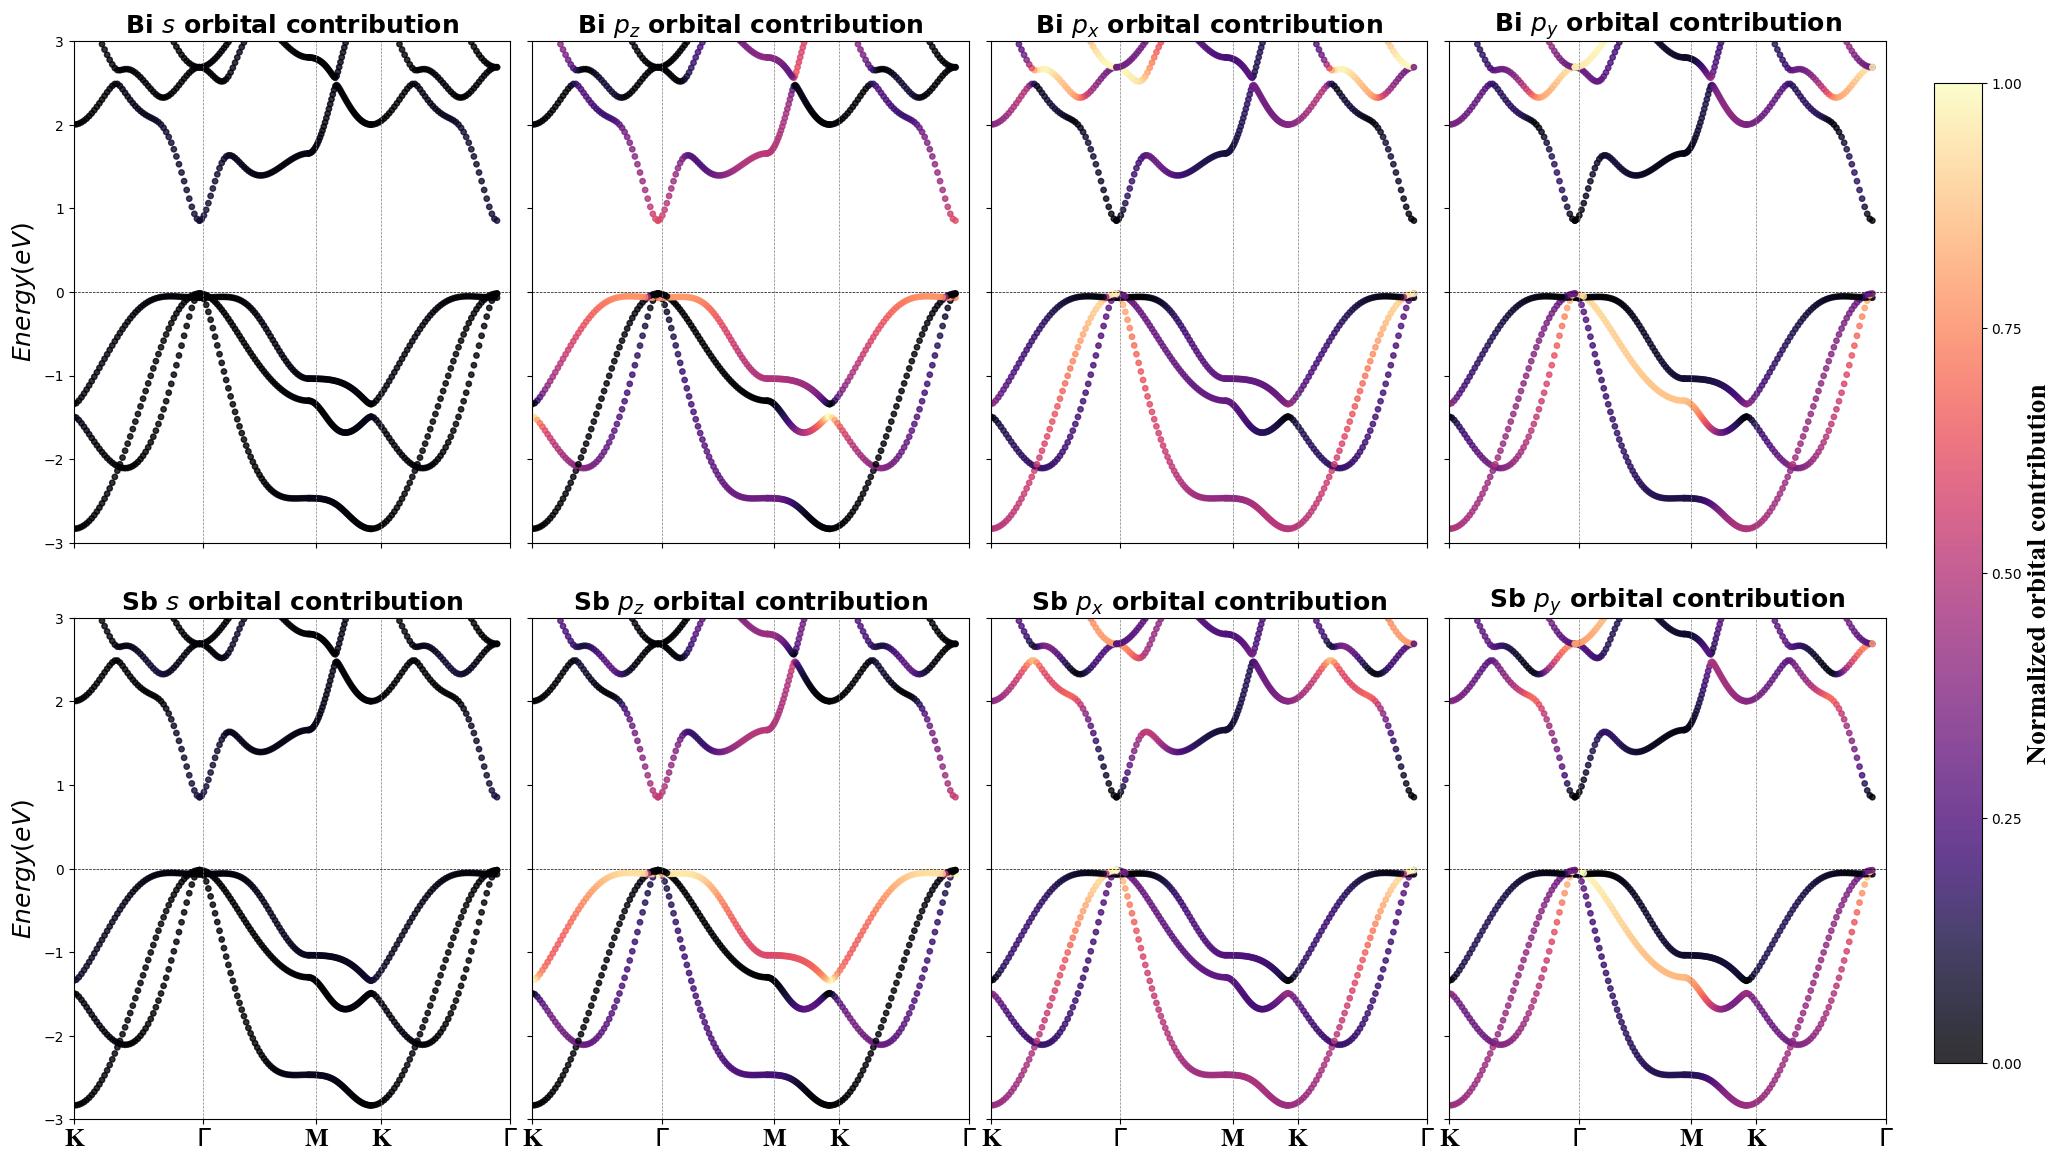

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load data for both atoms ---
data_bi = pd.read_csv(r"PBAND_Bi.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
data_sb = pd.read_csv(r"PBAND_Sb.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data_bi[0])
e = np.array(data_bi[1])

# --- Extract raw values ---
bi_vals = [data_bi[i].values.astype(float) for i in range(2, 6)]  # s, px, py, pz
sb_vals = [data_sb[i].values.astype(float) for i in range(2, 6)]

# --- Normalize each orbital INDEPENDENTLY to [0, 1] ---
def local_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

bi_norms = [local_norm(v) for v in bi_vals]
sb_norms = [local_norm(v) for v in sb_vals]


orbitals = [bi_norms[0],bi_norms[2], bi_norms[3], bi_norms[1],
            sb_norms[0],sb_norms[2], sb_norms[3], sb_norms[1]] 

names = ['Bi $s$', 'Bi $p_z$', 'Bi $p_x$', 'Bi $p_y$',
         'Sb $s$',  'Sb $p_z$', 'Sb $p_x$', 'Sb $p_y$']

cmap     = 'magma'

high_symmetry_points = [0, 0.982, 1.833, 2.324, 3.306]
high_symmetry_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

fig, axes = plt.subplots(2, 4, figsize=(24, 14), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, hspace=0.15, wspace=0.05)
axes = axes.flatten()

last_scatter = None

for idx, (orbital, name) in enumerate(zip(orbitals, names)):
    ax = axes[idx]

    scatter = ax.scatter(
        k, e,
        c=orbital,
        s=15, cmap=cmap, alpha=0.8,
        vmin=0, vmax=1
    )
    last_scatter = scatter

    ax.set_title(f'{name} orbital contribution', fontsize=18, fontweight='bold')
    ax.set_ylim(-3, 3)
    ax.set_xlim(min(k), max(k))

    for x in high_symmetry_points:
        ax.axvline(x=x, color='gray', linestyle='--', lw=0.5)
    ax.axhline(0, ls='--', lw=0.5, color='black')

    # x-axis tick labels for all rows (since they share x-axis)
    ax.set_xticks(high_symmetry_points)
    ax.set_xticklabels(high_symmetry_labels,fontsize=18,fontname="Times New Roman", fontweight="bold")

    # y-axis label only on left column
    if idx % 4 == 0:
        ax.set_ylabel(r'$Energy (eV)$',fontsize=18,fontname="Times New Roman")

# --- Single global colorbar on the right ---
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
cbar.set_label('Normalized orbital contribution',fontsize=20,fontname="Times New Roman", fontweight="bold")
cbar.ax.tick_params(labelsize=10)
plt.savefig("orbital_composed_bands.png", dpi=150, bbox_inches="tight")
plt.show()

Dataset 1: 456 points kept (out of 3249) in window [-1.7500, -1.5500] eV
Dataset 2: 120 points kept (out of 3249) in window [-1.7500, -1.5500] eV


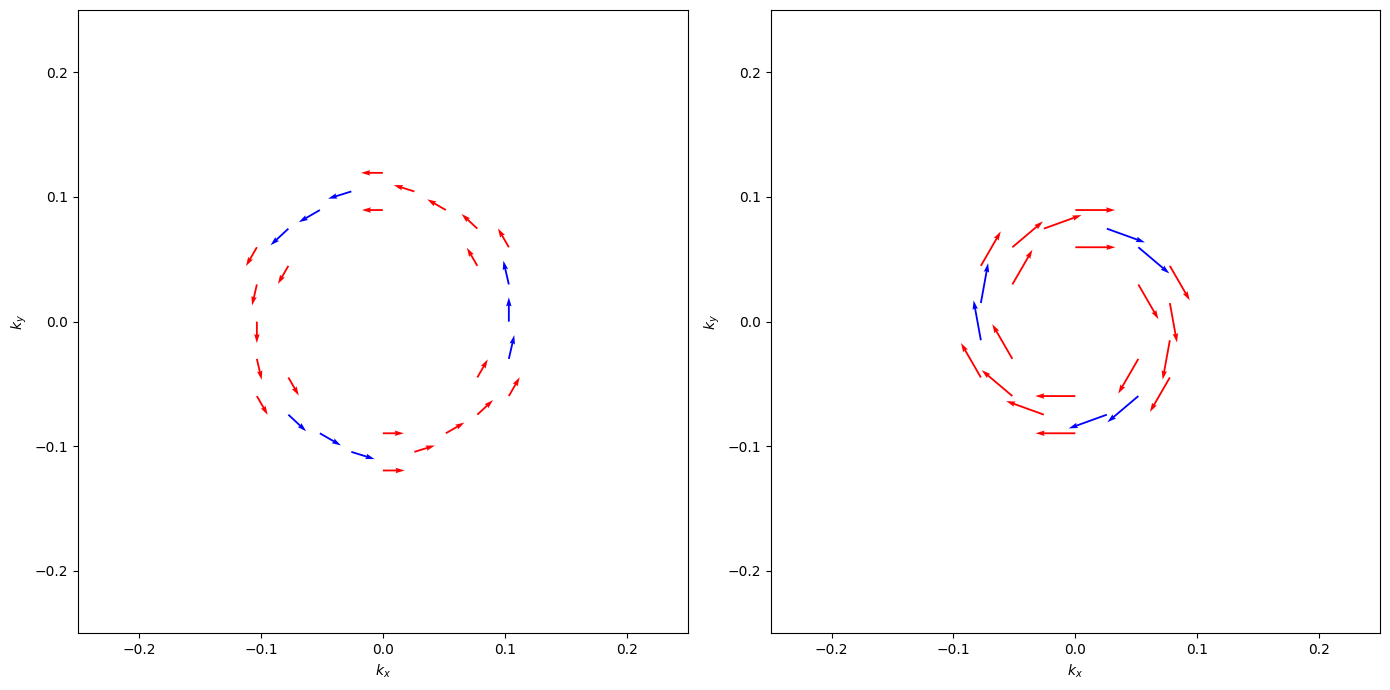

In [15]:
"""
Spin texture plotter for two datasets (e.g., two W-shaped bands above E_F).

Each data file must be plain text / whitespace- or comma-separated with 6 columns:
    k_x   k_y   E   S_x   S_y   S_z

Workflow:
    1. Load both datasets.
    2. Mask each dataset to keep only points with E in [E0 - dE, E0 + dE].
    3. Plot in-plane spin texture (S_x, S_y) as quiver arrows, colored by the
       SIGN of S_z only (two colors: one for S_z > 0, one for S_z < 0).

Edit the CONFIG block below to point to your files and set E0 / dE.
"""

import numpy as np
import matplotlib.pyplot as plt

# =========================== CONFIG ===========================
# Path to your two data files
DATA_FILE_1 = "21-SPINTEXTURE_2D_GAMMA_CENTER.dat"
DATA_FILE_2 = "22-SPINTEXTURE_2D_GAMMA_CENTER.dat"

# Energy window: keep points with E0 - dE <= E <= E0 + dE
E0 = -1.65      # basis energy (eV), e.g. 50 meV above E_F
dE = 0.1     # half-width of energy window (eV)

# Column indices (0-indexed) in the data files: kx, ky, E, Sx, Sy, Sz
COLS = dict(kx=0, ky=1, E=2, Sx=3, Sy=4, Sz=5)

# Colors for S_z sign
COLOR_SZ_POS = "red"
COLOR_SZ_NEG = "blue"

COLOR_SZ_POS_2 = "red"
COLOR_SZ_NEG_2 = "blue"

# Quiver appearance
ARROW_SCALE = None      # None = matplotlib auto-scales; set a number to fix arrow length
ARROW_WIDTH = 0.003

# Titles for the two subplots
TITLE_1 = "Dataset 1"
TITLE_2 = "Dataset 2"

ALPHA_1 = 1.0
ALPHA_2 = 1.0
 
# Labels for the two datasets (used in the legend)
LABEL_1 = "Dataset 1"
LABEL_2 = "Dataset 2"

TITLE = "Spin Texture"

# Output figure filename
OUTPUT_FIGURE = "spin_texture.png"
# ================================================================
def load_data(filepath):
    """Load a whitespace/comma-separated 6-column data file."""
    data = np.loadtxt(filepath, delimiter=None)
    return {
        "kx": data[:, COLS["kx"]],
        "ky": data[:, COLS["ky"]],
        "E": data[:, COLS["E"]],
        "Sx": data[:, COLS["Sx"]],
        "Sy": data[:, COLS["Sy"]],
        "Sz": data[:, COLS["Sz"]],
    }
 
 
def mask_energy_window(d, E0, dE):
    """Return only the entries with E in [E0 - dE, E0 + dE]."""
    mask = (d["E"] >= E0 - dE) & (d["E"] <= E0 + dE)
    return {key: val[mask] for key, val in d.items()}
 
 
def plot_spin_texture(ax, d, label_prefix, color_pos, color_neg):
    """Quiver plot of (Sx, Sy) colored by sign of Sz, on the given axis."""
    pos = d["Sz"] >= 0
    neg = ~pos
 
    ax.quiver(
        d["kx"][pos], d["ky"][pos], d["Sx"][pos], d["Sy"][pos],
        color=color_pos, scale=ARROW_SCALE, width=ARROW_WIDTH,
        label=f"{label_prefix}: $S_z > 0$",
    )
    ax.quiver(
        d["kx"][neg], d["ky"][neg], d["Sx"][neg], d["Sy"][neg],
        color=color_neg, scale=ARROW_SCALE, width=ARROW_WIDTH,
        label=f"{label_prefix}: $S_z < 0$",
    )
 
 
def main():
    d1 = load_data(DATA_FILE_1)
    d2 = load_data(DATA_FILE_2)
 
    d1_masked = mask_energy_window(d1, E0, dE)
    d2_masked = mask_energy_window(d2, E0, dE)
 
    print(f"Dataset 1: {len(d1_masked['E'])} points kept "
          f"(out of {len(d1['E'])}) in window [{E0-dE:.4f}, {E0+dE:.4f}] eV")
    print(f"Dataset 2: {len(d2_masked['E'])} points kept "
          f"(out of {len(d2['E'])}) in window [{E0-dE:.4f}, {E0+dE:.4f}] eV")
 
    fig, ax = plt.subplots(1,2,figsize=(14, 7))
 
    plot_spin_texture(ax[0], d1_masked, LABEL_1, COLOR_SZ_POS,COLOR_SZ_NEG)
    plot_spin_texture(ax[1], d2_masked, LABEL_2, COLOR_SZ_POS_2,COLOR_SZ_NEG_2)
 
    ax[0].set_xlabel(r"$k_x$")
    ax[0].set_ylabel(r"$k_y$")
    ax[1].set_xlabel(r"$k_x$")
    ax[1].set_ylabel(r"$k_y$")    
    ax[0].set_xlim(-0.25,0.25)
    ax[0].set_ylim(-0.25,0.25)
    ax[1].set_xlim(-0.25,0.25)
    ax[1].set_ylim(-0.25,0.25)
    fig.tight_layout()
    #fig.savefig(OUTPUT_FIGURE, dpi=300)
    plt.show()
 
 
if __name__ == "__main__":
    main()

Dataset 1: 18 points kept (out of 3249) in radius window [0.0900, 0.1100]
Dataset 2: 18 points kept (out of 3249) in radius window [0.0900, 0.1100]


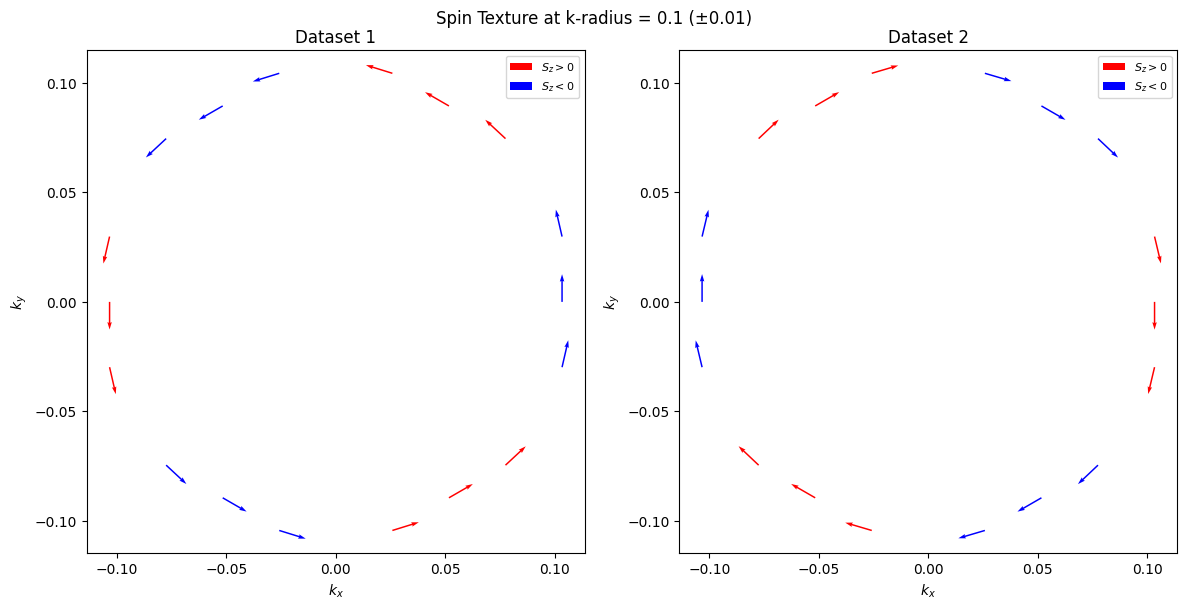

In [24]:
"""
Spin texture plotter for two datasets (e.g., two W-shaped bands above E_F).

Each data file must be plain text / whitespace- or comma-separated with 6 columns:
    k_x   k_y   E   S_x   S_y   S_z

Workflow:
    1. Load both datasets.
    2. Mask each dataset to keep only points where sqrt(kx^2 + ky^2) is
       approximately equal to a fixed k-radius (within a tolerance dK).
    3. Plot in-plane spin texture (S_x, S_y) as quiver arrows, colored by the
       SIGN of S_z only (two colors: one for S_z > 0, one for S_z < 0).

Edit the CONFIG block below to point to your files and set K_RADIUS / dK.
"""

import numpy as np
import matplotlib.pyplot as plt

# =========================== CONFIG ===========================
# Path to your two data files
DATA_FILE_1 = "21-SPINTEXTURE_2D_GAMMA_CENTER.dat"
DATA_FILE_2 = "22-SPINTEXTURE_2D_GAMMA_CENTER.dat"

# Radius window: keep points with |sqrt(kx^2 + ky^2) - K_RADIUS| <= dK
K_RADIUS = 0.1    # target k-radius (in same units as kx, ky)
dK = 0.01         # half-width of the radius window

# Column indices (0-indexed) in the data files: kx, ky, E, Sx, Sy, Sz
COLS = dict(kx=0, ky=1, E=2, Sx=3, Sy=4, Sz=5)

# Colors for S_z sign
COLOR_SZ_POS = "red"
COLOR_SZ_NEG = "blue"

# Quiver appearance
ARROW_SCALE = None      # None = matplotlib auto-scales; set a number to fix arrow length
ARROW_WIDTH = 0.003

# Titles for the two subplots
TITLE_1 = "Dataset 1"
TITLE_2 = "Dataset 2"

# Output figure filename
OUTPUT_FIGURE = "spin_texture.png"
# ================================================================


def load_data(filepath):
    """Load a whitespace/comma-separated 6-column data file."""
    data = np.loadtxt(filepath, delimiter=None)
    return {
        "kx": data[:, COLS["kx"]],
        "ky": data[:, COLS["ky"]],
        "E": data[:, COLS["E"]],
        "Sx": data[:, COLS["Sx"]],
        "Sy": data[:, COLS["Sy"]],
        "Sz": data[:, COLS["Sz"]],
    }


def mask_k_radius(d, k_radius, dk):
    """Return only the entries with sqrt(kx^2 + ky^2) in [k_radius - dk, k_radius + dk]."""
    k_mag = np.sqrt(d["kx"] ** 2 + d["ky"] ** 2)
    mask = (k_mag >= k_radius - dk) & (k_mag <= k_radius + dk)
    return {key: val[mask] for key, val in d.items()}


def plot_spin_texture(ax, d, title):
    """Quiver plot of (Sx, Sy) colored by sign of Sz."""
    pos = d["Sz"] >= 0
    neg = ~pos

    ax.quiver(
        d["kx"][pos], d["ky"][pos], d["Sx"][pos], d["Sy"][pos],
        color=COLOR_SZ_POS, scale=ARROW_SCALE, width=ARROW_WIDTH,
        label="$S_z > 0$",
    )
    ax.quiver(
        d["kx"][neg], d["ky"][neg], d["Sx"][neg], d["Sy"][neg],
        color=COLOR_SZ_NEG, scale=ARROW_SCALE, width=ARROW_WIDTH,
        label="$S_z < 0$",
    )

    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)


def main():
    d1 = load_data(DATA_FILE_1)
    d2 = load_data(DATA_FILE_2)

    d1_masked = mask_k_radius(d1, K_RADIUS, dK)
    d2_masked = mask_k_radius(d2, K_RADIUS, dK)

    print(f"Dataset 1: {len(d1_masked['kx'])} points kept "
          f"(out of {len(d1['kx'])}) in radius window [{K_RADIUS-dK:.4f}, {K_RADIUS+dK:.4f}]")
    print(f"Dataset 2: {len(d2_masked['kx'])} points kept "
          f"(out of {len(d2['kx'])}) in radius window [{K_RADIUS-dK:.4f}, {K_RADIUS+dK:.4f}]")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    plot_spin_texture(axes[0], d1_masked, TITLE_1)
    plot_spin_texture(axes[1], d2_masked, TITLE_2)

    fig.suptitle(f"Spin Texture at k-radius = {K_RADIUS} (±{dK})")
    fig.tight_layout()
    #fig.savefig(OUTPUT_FIGURE, dpi=300)
    plt.show()


if __name__ == "__main__":
    main()

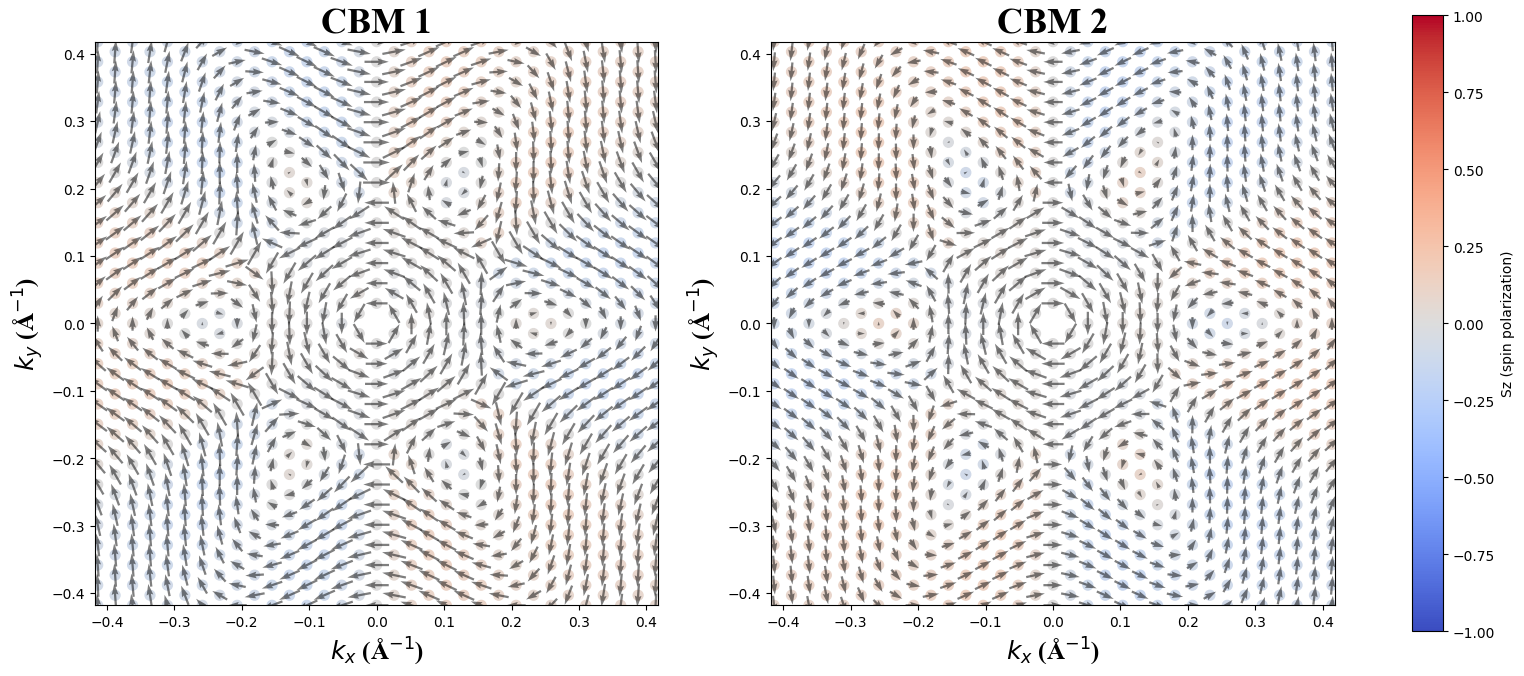

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

GAMMA_TOL = 1e-6

# ── Load data ─────────────────────────────────────────────────────────────────
data_spin_1 = np.loadtxt(
    "21-SPINTEXTURE_2D_GAMMA_CENTER.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx_1 = data_spin_1[:, 0]
ky_1 = data_spin_1[:, 1]
Sx_1 = data_spin_1[:, 2]
Sy_1 = data_spin_1[:, 3]
Sz_1 = data_spin_1[:, 4]


data_spin_2 = np.loadtxt(
    "22-SPINTEXTURE_2D_GAMMA_CENTER.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx_2 = data_spin_2[:, 0]
ky_2 = data_spin_2[:, 1]
Sx_2 = data_spin_2[:, 2]
Sy_2 = data_spin_2[:, 3]
Sz_2 = data_spin_2[:, 4]


# ── Helper: crop to the largest square fully covered by data, drop Gamma ─────
def crop_to_square_and_mask_gamma(kx, ky, Sx, Sy, Sz, gamma_tol=GAMMA_TOL):
    kx_unique = np.unique(kx)
    ky_unique = np.unique(ky)

    # For each ky row, find the kx extent; take the tightest (inner square)
    kx_min_per_ky = [kx[ky == y].min() for y in ky_unique]
    kx_max_per_ky = [kx[ky == y].max() for y in ky_unique]
    kx_lo = np.max(kx_min_per_ky)
    kx_hi = np.min(kx_max_per_ky)

    # For each kx column, find the ky extent; take the tightest
    ky_min_per_kx = [ky[kx == x].min() for x in kx_unique]
    ky_max_per_kx = [ky[kx == x].max() for x in kx_unique]
    ky_lo = np.max(ky_min_per_kx)
    ky_hi = np.min(ky_max_per_kx)

    # Use the tightest bound across both axes to guarantee no empty corners
    k_sq = min(abs(kx_lo), abs(kx_hi), abs(ky_lo), abs(ky_hi))

    mask = (
        (np.abs(kx) <= k_sq)
        & (np.abs(ky) <= k_sq)
        & (np.sqrt(kx**2 + ky**2) > gamma_tol)
    )

    return kx[mask], ky[mask], Sx[mask], Sy[mask], Sz[mask], k_sq


kx_1p, ky_1p, Sx_1p, Sy_1p, Sz_1p, k_sq_1 = crop_to_square_and_mask_gamma(
    kx_1, ky_1, Sx_1, Sy_1, Sz_1
)
kx_2p, ky_2p, Sx_2p, Sy_2p, Sz_2p, k_sq_2 = crop_to_square_and_mask_gamma(
    kx_2, ky_2, Sx_2, Sy_2, Sz_2
)


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

norm = Normalize(vmin=-1, vmax=1)

scale1 = 10
scale2 = 12

datasets = [
    (axes[0], kx_1p, ky_1p, Sx_1p, Sy_1p, Sz_1p, k_sq_1, "CBM 1"),
    (axes[1], kx_2p, ky_2p, Sx_2p, Sy_2p, Sz_2p, k_sq_2, "CBM 2"),
]

for ax, kx_p, ky_p, Sx_p, Sy_p, Sz_p, k_sq, title in datasets:
    sc = ax.scatter(kx_p, ky_p, c=Sz_p, cmap="coolwarm", norm=norm, s=50, zorder=1)
    if title == "CBM 1": scale = 9
    if title == "CBM 2": scale = 12
    ax.quiver(
        kx_p, ky_p, Sx_p, Sy_p,
        pivot="mid",
        scale=scale,
        scale_units="xy",
        width=0.004,
        color="black",
        alpha=0.5,
        zorder=2,
    )

    ax.set_xlim(-k_sq, k_sq)
    ax.set_ylim(-k_sq, k_sq)
    ax.set_xlabel(r"$k_x$ (Å$^{-1}$)", fontsize=18, fontname="Times New Roman", fontweight="bold")
    ax.set_ylabel(r"$k_y$ (Å$^{-1}$)", fontsize=18, fontname="Times New Roman", fontweight="bold")
    ax.set_title(title, fontsize=26, fontname="Times New Roman", fontweight="bold")
    ax.set_aspect("equal")

fig.colorbar(sc, ax=axes, label="Sz (spin polarization)", shrink=0.8)

plt.savefig("bisb_spin_texture.png", dpi=150, bbox_inches="tight")
plt.show()

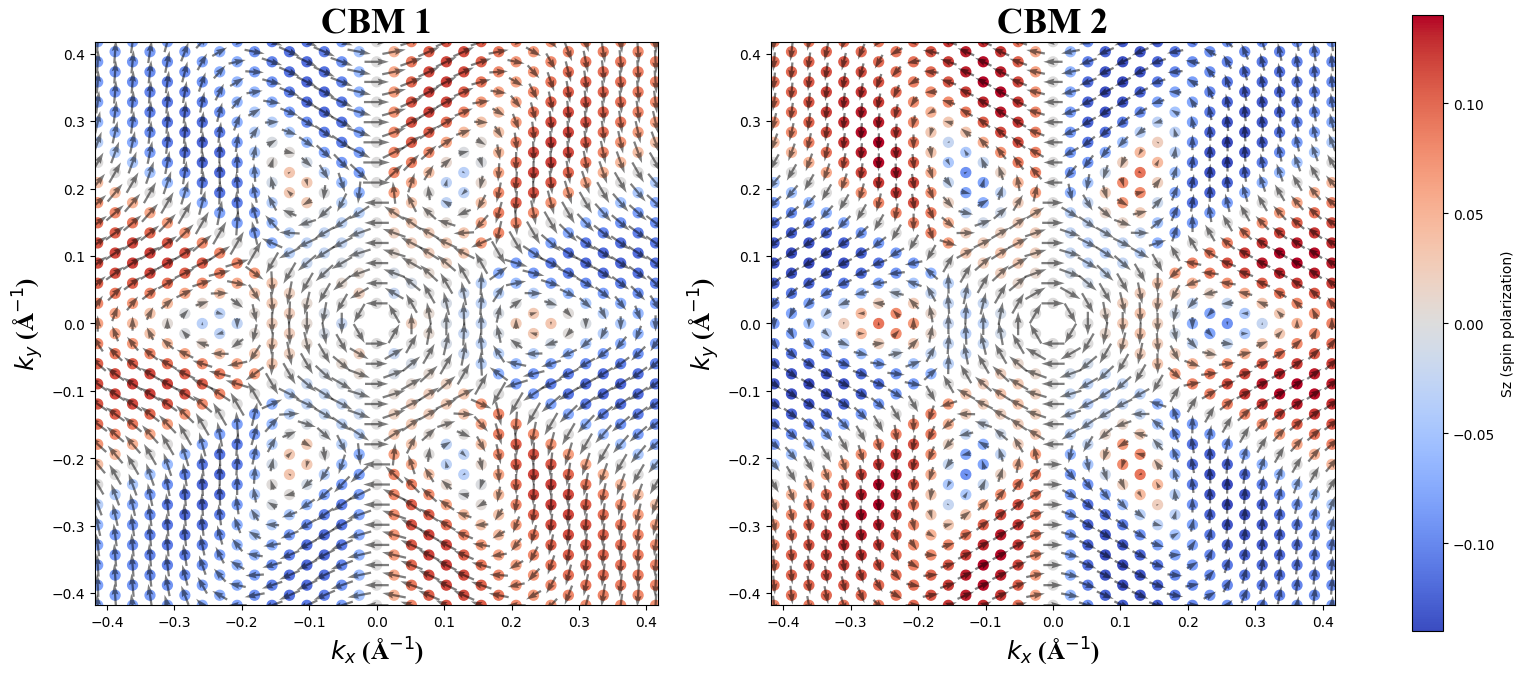

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

GAMMA_TOL = 1e-6

# ── Load data ─────────────────────────────────────────────────────────────────
data_spin_1 = np.loadtxt(
    "21-SPINTEXTURE_2D_GAMMA_CENTER.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx_1 = data_spin_1[:, 0]
ky_1 = data_spin_1[:, 1]
Sx_1 = data_spin_1[:, 2]
Sy_1 = data_spin_1[:, 3]
Sz_1 = data_spin_1[:, 4]


data_spin_2 = np.loadtxt(
    "22-SPINTEXTURE_2D_GAMMA_CENTER.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx_2 = data_spin_2[:, 0]
ky_2 = data_spin_2[:, 1]
Sx_2 = data_spin_2[:, 2]
Sy_2 = data_spin_2[:, 3]
Sz_2 = data_spin_2[:, 4]


# ── Helper: crop to the largest square fully covered by data, drop Gamma ─────
def crop_to_square_and_mask_gamma(kx, ky, Sx, Sy, Sz, gamma_tol=GAMMA_TOL):
    kx_unique = np.unique(kx)
    ky_unique = np.unique(ky)

    # For each ky row, find the kx extent; take the tightest (inner square)
    kx_min_per_ky = [kx[ky == y].min() for y in ky_unique]
    kx_max_per_ky = [kx[ky == y].max() for y in ky_unique]
    kx_lo = np.max(kx_min_per_ky)
    kx_hi = np.min(kx_max_per_ky)

    # For each kx column, find the ky extent; take the tightest
    ky_min_per_kx = [ky[kx == x].min() for x in kx_unique]
    ky_max_per_kx = [ky[kx == x].max() for x in kx_unique]
    ky_lo = np.max(ky_min_per_kx)
    ky_hi = np.min(ky_max_per_kx)

    # Use the tightest bound across both axes to guarantee no empty corners
    k_sq = min(abs(kx_lo), abs(kx_hi), abs(ky_lo), abs(ky_hi))

    mask = (
        (np.abs(kx) <= k_sq)
        & (np.abs(ky) <= k_sq)
        & (np.sqrt(kx**2 + ky**2) > gamma_tol)
    )

    return kx[mask], ky[mask], Sx[mask], Sy[mask], Sz[mask], k_sq


kx_1p, ky_1p, Sx_1p, Sy_1p, Sz_1p, k_sq_1 = crop_to_square_and_mask_gamma(
    kx_1, ky_1, Sx_1, Sy_1, Sz_1
)
kx_2p, ky_2p, Sx_2p, Sy_2p, Sz_2p, k_sq_2 = crop_to_square_and_mask_gamma(
    kx_2, ky_2, Sx_2, Sy_2, Sz_2
)


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Normalize based on the actual masked Sz range (symmetric around 0 so
# "coolwarm" stays white at Sz=0), instead of a fixed +/-1 that washes out
# the colors once the high-Sz Gamma point has been excluded.
sz_max = max(np.abs(Sz_1p).max(), np.abs(Sz_2p).max())
norm = Normalize(vmin=-sz_max, vmax=sz_max)

datasets = [
    (axes[0], kx_1p, ky_1p, Sx_1p, Sy_1p, Sz_1p, k_sq_1, "CBM 1"),
    (axes[1], kx_2p, ky_2p, Sx_2p, Sy_2p, Sz_2p, k_sq_2, "CBM 2"),
]

for ax, kx_p, ky_p, Sx_p, Sy_p, Sz_p, k_sq, title in datasets:
    sc = ax.scatter(kx_p, ky_p, c=Sz_p, cmap="coolwarm", norm=norm, s=50, zorder=1)
    if title == "CBM 1":
        scale = 9
    if title == "CBM 2":
        scale = 12
    ax.quiver(
        kx_p, ky_p, Sx_p, Sy_p,
        pivot="mid",
        scale=scale,
        scale_units="xy",
        width=0.004,
        color="black",
        alpha=0.5,
        zorder=2,
    )

    ax.set_xlim(-k_sq, k_sq)
    ax.set_ylim(-k_sq, k_sq)
    ax.set_xlabel(r"$k_x$ (Å$^{-1}$)", fontsize=18, fontname="Times New Roman", fontweight="bold")
    ax.set_ylabel(r"$k_y$ (Å$^{-1}$)", fontsize=18, fontname="Times New Roman", fontweight="bold")
    ax.set_title(title, fontsize=26, fontname="Times New Roman", fontweight="bold")
    ax.set_aspect("equal")

fig.colorbar(sc, ax=axes, label="Sz (spin polarization)", shrink=0.8)

plt.savefig("bisb_spin_texture.png", dpi=150, bbox_inches="tight")
plt.show()